# SST空间分布分析

本notebook用于：
1. 加载SST数据（通过函数）
2. 绘制SST空间分布图
3. 使用geocat.viz.util进行专业格式化

In [35]:
# ============================================================================
# 导入必要的库
# ============================================================================
import os
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import glob
import cmaps

# 尝试导入 geocat.viz
try:
    import geocat.viz.util as gvutil
    USE_GEOCAT = True
    print("✅ geocat.viz loaded successfully")
except ImportError:
    USE_GEOCAT = False
    print("⚠️  geocat.viz not available, using basic style")

# 图形保存目录
fig_save_dir = '/work/mh1498/m301257/fig'
os.makedirs(fig_save_dir, exist_ok=True)

print("✅ 模块加载完成")

✅ geocat.viz loaded successfully
✅ 模块加载完成


## 数据加载函数

In [36]:
# ============================================================================
# SST数据加载函数
# ============================================================================

def load_sst_data(experiment, data_dir="/work/mh1498/m301257/processed_data_lat_30/2d_layers"):
    """
    加载指定实验的SST数据
    
    Parameters:
    -----------
    experiment : str
        实验名称：'cntl', 'p4k', '4co2'
    data_dir : str
        数据根目录
        
    Returns:
    --------
    xarray.DataArray
        SST数据
    """
    print(f"📂 加载 {experiment.upper()} SST数据...")
    
    # 构建路径
    ts_path = f"{data_dir}/ts_{experiment}"
    ts_files = glob.glob(f"{ts_path}/*.nc")
    
    if len(ts_files) == 0:
        raise FileNotFoundError(f"❌ 未找到文件: {ts_path}/*.nc")
    
    # 加载数据
    ds = xr.open_dataset(ts_files[0])
    
    # 查找变量名（可能是ts, tos, sst, SST等）
    var_name = None
    for v in ['ts', 'tos', 'sst', 'SST']:
        if v in ds.data_vars:
            var_name = v
            break
    
    if var_name is None:
        raise ValueError(f"❌ 未找到SST变量，可用变量: {list(ds.data_vars)}")
    
    sst = ds[var_name]
    print(f"   ✅ {experiment.upper()} SST加载完成: {sst.shape}")
    print(f"   变量名: {var_name}, 范围: [{sst.min().values:.2f}, {sst.max().values:.2f}] K")
    
    return sst


def load_ocean_mask(mask_path='/work/mh1498/m301257/processed_data_lat_30/3d_layers/mask_cntl/cell_sea_land_mask_2deg.nc'):
    """
    加载海洋掩码
    
    Parameters:
    -----------
    mask_path : str
        掩码文件路径
        
    Returns:
    --------
    xarray.DataArray
        海洋掩码（True=海洋, False=陆地）
    """
    print("📂 加载海洋掩码...")
    ds = xr.open_dataset(mask_path)
    # 查找掩码变量
    var_name = list(ds.data_vars)[0]
    mask_raw = ds[var_name]
    
    # 根据实际数据：负值表示海洋，正值表示陆地
    # 创建布尔掩码：True=海洋，False=陆地
    ocean_mask = mask_raw < 0
    
    print(f"   ✅ 海洋掩码加载完成: {ocean_mask.shape}")
    print(f"   海洋像素数: {ocean_mask.sum().values}")
    print(f"   陆地像素数: {(~ocean_mask).sum().values}")
    
    return ocean_mask


print("✅ 数据加载函数定义完成")

✅ 数据加载函数定义完成


## 绘图函数

## 主程序：加载数据并绘图

In [37]:
# ============================================================================
# 1. 加载数据
# ============================================================================

# 加载SST数据
sst_cntl = load_sst_data('cntl')
sst_p4k = load_sst_data('p4k')


# 加载海洋掩码（修正后：负值=海洋保留，正值=陆地掩盖）
ocean_mask = load_ocean_mask()

print("\n✅ 所有数据加载完成")

📂 加载 CNTL SST数据...
   ✅ CNTL SST加载完成: (5114, 37, 180)
   变量名: ts, 范围: [232.48, 320.20] K
📂 加载 P4K SST数据...
   ✅ P4K SST加载完成: (5114, 37, 180)
   变量名: ts, 范围: [232.48, 320.20] K
📂 加载 P4K SST数据...
   ✅ P4K SST加载完成: (5114, 37, 180)
   变量名: ts, 范围: [239.48, 325.13] K
📂 加载海洋掩码...
   ✅ 海洋掩码加载完成: (37, 180)
   海洋像素数: 4625
   陆地像素数: 2035

✅ 所有数据加载完成
   变量名: ts, 范围: [239.48, 325.13] K
📂 加载海洋掩码...
   ✅ 海洋掩码加载完成: (37, 180)
   海洋像素数: 4625
   陆地像素数: 2035

✅ 所有数据加载完成



🎨 绘制SST空间分布图
   ✅ CNTL: 平均SST = 25.96°C
   ✅ CNTL: 平均SST = 25.96°C
   ✅ P4K: 平均SST = 29.96°C
   ✅ P4K: 平均SST = 29.96°C


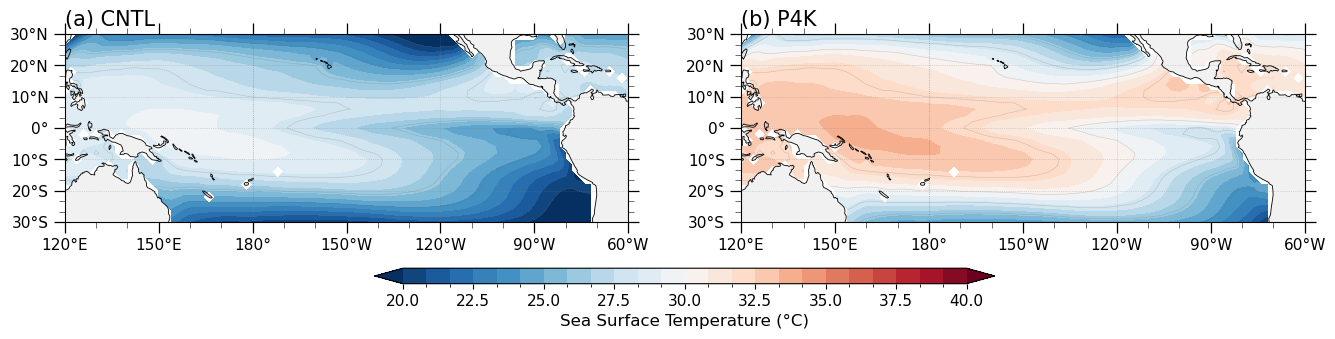

In [42]:
# ============================================================================
# SST空间分布绘图函数
# ============================================================================

def plot_sst_spatial_distribution(
        sst_data_dict,
        ocean_mask=None,
        region=(-30, 30, 0, 360),
        time_average=True,
        figsize=(18, 6),
        save_path=None):
    """
    绘制SST空间分布图
    
    Parameters:
    -----------
    sst_data_dict : dict
        包含各实验SST数据的字典，例如：
        {'CNTL': sst_cntl, 'P4K': sst_p4k, '4CO2': sst_4co2}
    ocean_mask : xarray.DataArray, optional
        海洋掩码
    region : tuple
        区域范围 (lat_min, lat_max, lon_min, lon_max)
    time_average : bool
        是否对时间维度取平均
    figsize : tuple
        图形大小
    save_path : str, optional
        保存路径（如果提供）
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
    """
    lat_min, lat_max, lon_min, lon_max = region
    n_exps = len(sst_data_dict)
    
    # 使用中心经度180°的投影
    proj = ccrs.PlateCarree(central_longitude=180)
    
    fig, axes = plt.subplots(1, n_exps, figsize=figsize,
                             subplot_kw={'projection': proj})
    
    if n_exps == 1:
        axes = [axes]
    
    # JGR风格colormap - 使用专业的海温配色
    sst_cmap = cmaps.MPL_RdBu_r
    
    print("\n" + "="*80)
    print("🎨 绘制SST空间分布图")
    print("="*80)
    subtitles = ['(a)','(b)']
    for idx, (exp_name, sst_data) in enumerate(sst_data_dict.items()):
        ax = axes[idx]
        
        # 时间平均
        if time_average and 'time' in sst_data.dims:
            sst_mean = sst_data.mean(dim='time')
        else:
            sst_mean = sst_data
        
        # 转换为摄氏度
        sst_mean_celsius = sst_mean - 273.15
        
        # 应用海洋掩码（保留海洋，掩盖陆地）
        if ocean_mask is not None:
            # ocean_mask是布尔数组：True=海洋，False=陆地
            # where会保留True的位置，将False的位置设为NaN
            sst_mean_celsius = sst_mean_celsius.where(ocean_mask)
        
        # 选择区域 - 先不选择，保留完整数据
        # 如果经度范围跨越0度经线，需要特殊处理
        if lon_min < lon_max:
            sst_region = sst_mean_celsius.sel(lat=slice(lat_min, lat_max),
                                              lon=slice(lon_min, lon_max))
        else:
            # 跨越0度经线的情况
            sst_region = sst_mean_celsius.sel(lat=slice(lat_min, lat_max))
        
        # 添加循环经度（使用geocat）
        if USE_GEOCAT:
            sst_region = gvutil.xr_add_cyclic_longitudes(sst_region, 'lon')
        
        # 确定colorbar范围（摄氏度）
        vmin = 20
        vmax = 40
        levels = np.linspace(vmin, vmax, 25)
        
        # 绘制填色图
        cf = sst_region.plot.contourf(
            ax=ax,
            levels=levels,
            cmap=sst_cmap,
            add_colorbar=False,
            transform=ccrs.PlateCarree(),
            extend='both',
            add_labels=False
        )
        
        # 绘制等值线
        contour_levels = np.arange(vmin, vmax+1, 2)
        sst_region.plot.contour(
            ax=ax,
            levels=contour_levels,
            colors='dimgray',
            alpha=0.3,
            linewidths=0.4,
            linestyles='solid',
            add_labels=False,
            transform=ccrs.PlateCarree()
        )
        
        # 添加陆地和海岸线 - JGR风格
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2, alpha=0.3)
        ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.6, zorder=3)
        
        # 设置坐标范围和刻度
        # 转换经度范围：对于central_longitude=180的投影，需要将0-360范围转换为-180到180
        lon_min_plot = lon_min - 180 if lon_min >= 180 else lon_min - 180
        lon_max_plot = lon_max - 180 if lon_max >= 180 else lon_max - 180
        
        # 确保范围正确
        if lon_min_plot > lon_max_plot:
            lon_min_plot, lon_max_plot = lon_max_plot, lon_min_plot
        
        if USE_GEOCAT:
            # 计算合适的刻度间隔
            lon_range = abs(lon_max_plot - lon_min_plot)
            if lon_range <= 60:
                lon_interval = 10
            elif lon_range <= 120:
                lon_interval = 20
            elif lon_range <= 180:
                lon_interval = 30
            else:
                lon_interval = 60
            
            lat_range = lat_max - lat_min
            if lat_range <= 20:
                lat_interval = 5
            else:
                lat_interval = 10
            
            gvutil.set_axes_limits_and_ticks(
                ax,
                xlim=(lon_min_plot, lon_max_plot),
                ylim=(lat_min, lat_max),
                xticks=np.arange(lon_min_plot, lon_max_plot+1, lon_interval),
                yticks=np.arange(lat_min, lat_max+1, lat_interval)
            )
            gvutil.add_major_minor_ticks(ax, labelsize=11)
            gvutil.add_lat_lon_ticklabels(ax)
        else:
            # 对于非geocat的情况，使用set_extent
            lon_extent_min = lon_min - 180
            lon_extent_max = lon_max - 180
            ax.set_extent([lon_extent_min, lon_extent_max, lat_min, lat_max],
                         crs=ccrs.PlateCarree(central_longitude=180))
            
            # 计算合适的刻度间隔
            lon_range = lon_max - lon_min
            if lon_range <= 60:
                lon_interval = 10
            elif lon_range <= 120:
                lon_interval = 20
            elif lon_range <= 180:
                lon_interval = 30
            else:
                lon_interval = 60
            
            lat_range = lat_max - lat_min
            if lat_range <= 20:
                lat_interval = 5
            else:
                lat_interval = 10
            
            ax.set_xticks(np.arange(lon_min, lon_max+1, lon_interval), crs=ccrs.PlateCarree())
            ax.set_yticks(np.arange(lat_min, lat_max+1, lat_interval), crs=ccrs.PlateCarree())
            ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=False))
            ax.yaxis.set_major_formatter(LatitudeFormatter())
            ax.tick_params(labelsize=11)
        
        # 添加gridlines
        gl = ax.gridlines(draw_labels=False, linestyle=':', alpha=0.5, linewidth=0.5, color='gray')
        
        # 设置标题 - JGR风格（不加粗）
        mean_sst = sst_region.mean().values
        ax.set_title(f'{subtitles[idx]} {exp_name}',
                    fontsize=15, loc='left')
        
        # 只在最后一个子图添加colorbar
        if idx == n_exps - 1:
            cbar = plt.colorbar(cf, ax=axes, orientation='horizontal',
                              pad=0.1, shrink=0.5, aspect=40)
            cbar.set_label('Sea Surface Temperature (°C)', fontsize=12)
            cbar.ax.tick_params(labelsize=11)
        
        print(f"   ✅ {exp_name}: 平均SST = {mean_sst:.2f}°C")
    # 
    # plt.tight_layout()
    
    # 保存图形
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n💾 图形已保存: {save_path}")
    
    print("="*80)
    return fig
# ============================================================================
# 2. 绘制SST气候态空间分布
# ============================================================================

# 准备数据字典
sst_dict = {
    'CNTL': sst_cntl,
    'P4K': sst_p4k,
}

# 绘图（可以自定义区域范围）
# 热带太平洋区域: 120°E-300°E (120°E-60°W)
fig1 = plot_sst_spatial_distribution(
    sst_dict,
    ocean_mask=ocean_mask,
    region=(-30, 30, 120, 300),  # 热带太平洋
    time_average=True,
    figsize=(16, 6),
    save_path=f'{fig_save_dir}/sst_climatology.png'
)

plt.show()